<a href="https://colab.research.google.com/github/akshara-git17/synent-task3-netflixeda-akshara_dave/blob/main/Task3_Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Exploratory Data Analysis (EDA)

## Synent Technologies Data Science Internship

### Submitted By:
Akshara Dave

### Objective
The objective of this project is to analyze Netflix content and identify trends, patterns, and insights using Exploratory Data Analysis (EDA).

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Dataset Overview

Before performing analysis, we need to understand the structure of the dataset, including the number of rows, columns, data types, and missing values.

In [ ]:
#to get the number of rows(Netflix titles) and columns(features) of the dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (8807, 12)


In [ ]:
#to check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#summary statistics
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# Column Description

- *show_id* : Unique identifier for each title
- *type* : Movie or TV Show
- *title* : Name of the content
- *director* : Director name
- *cast* : Actors/Actresses
- *country* : Country of origin
- *date_added* : Date added to Netflix
- *release_year* : Release year
- *rating* : Content rating
- *duration*: Movie duration or TV seasons
- *listed_in* : Genre/category
- *description* : Brief summary

In [ ]:
#to show exactly how many missing values each column contains
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# Data Cleaning

Before performing analysis, the dataset is cleaned by handling missing values, checking duplicates, and preparing columns for further exploration.

In [ ]:
# Filling missing text values

df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Not Available")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna("Not Rated")

df["date_added"] = df["date_added"].fillna("Unknown")

df["duration"] = df["duration"].fillna("Unknown")

In [ ]:
#verifying missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Since all the missing values are all '0',there are no more missing values.

In [ ]:
#checking duplicate records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
#Removing duplicates (if any)
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


In [ ]:
#verifying data shape (number of rows and columns)
print(df.shape)

(8807, 12)


After verifying data shape we get to know that no rows or columns were removed.

In [ ]:
#Converting Date Column
df["date_added"].head()

,date_added
0,"September 25, 2021"
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"


In [ ]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

I converted "date_added" data type because later I will analyze content by year.

The use of *errors='coerce'* here is to convert the invalid date found by Pandas to *NaT* instead of crashing.


In [ ]:
#creating year added column
df["year_added"] = df["date_added"].dt.year

In [ ]:
df[["date_added", "year_added"]].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [ ]:
#checking for missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


98 records contained missing date information and were retained as null values because the exact date could not be reliably inferred.

# Exploratory Data Analysis :

## Analysis 1: Movies vs TV Shows
What type of content dominates Netflix's catalog?

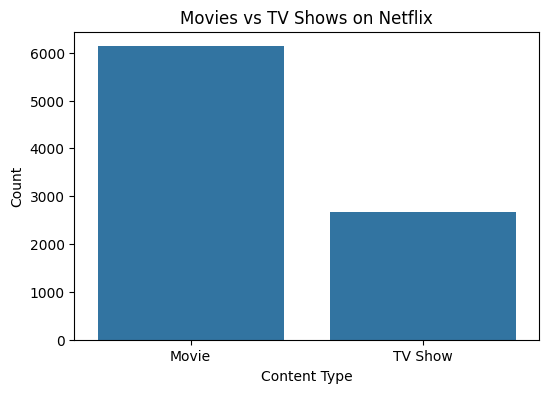

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

### Insight from this analysis :
Movies significantly outnumber TV Shows on Netflix. This suggests that Netflix's content library is primarily focused on movies, although TV Shows also represent an important portion of the platform's offerings.

## Analysis 2: Netflix Content Growth Over Time
How has Netflix expanded its content library over the years?

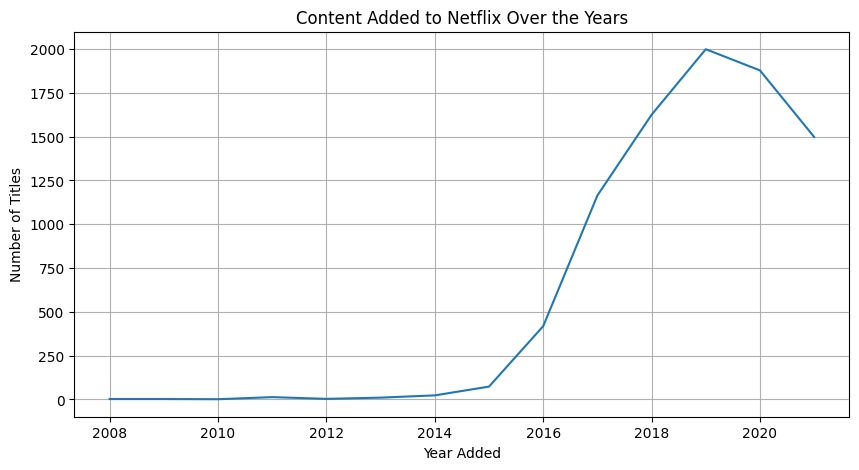

In [ ]:
plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot(kind='line')

plt.title('Content Added to Netflix Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

### Insight from this analysis :

The number of titles added to Netflix increased significantly over the years, indicating rapid platform growth and content expansion. The trend reflects Netflix's increasing investment in content acquisition and production.

## Analysis 3: Top Contributing Countries
Which countries contribute the most content to Netflix?

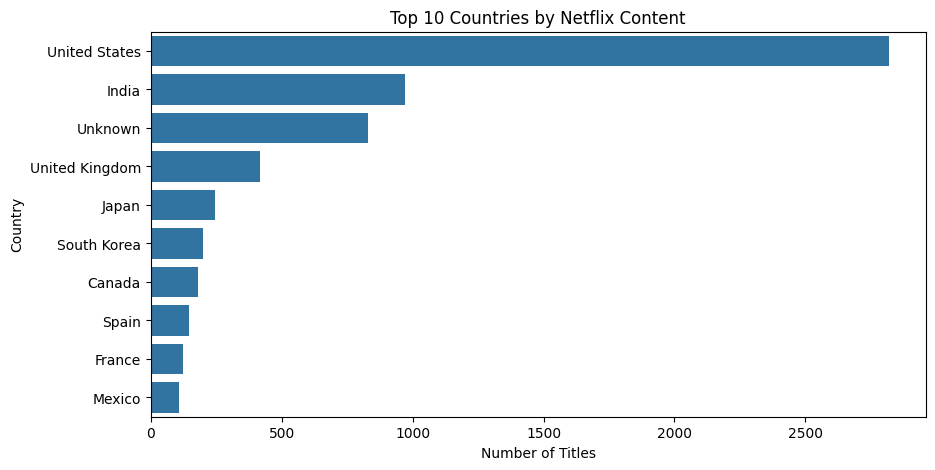

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

### Insight from this analysis :

The United States contributes the largest number of titles to Netflix, followed by other major content-producing countries. This highlights Netflix's strong presence in international markets while maintaining a dominant U.S. content base.

## Analysis 4: Ratings Distribution
Which audience categories are most targeted by Netflix content?

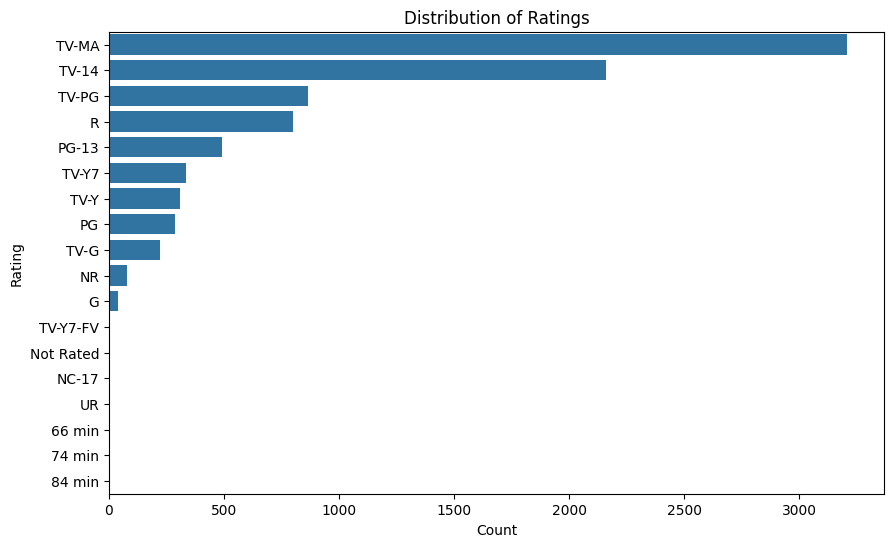

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index
)

plt.title('Distribution of Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

### Insight from this analysis :

TV-MA and TV-14 are among the most common ratings on Netflix, indicating that a large portion of content is designed for mature and teenage audiences.

## Analysis 5: Most Popular Genres
Which genres are most common on Netflix?

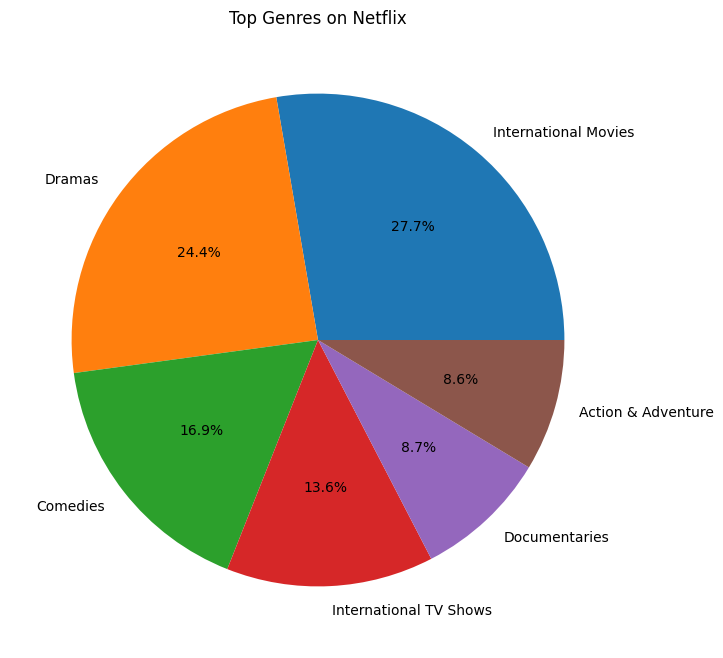

In [ ]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(6)

plt.figure(figsize=(8,8))

plt.pie(
    top_genres.values,
    labels=top_genres.index,
    autopct='%1.1f%%'
)

plt.title('Top Genres on Netflix')

plt.show()

### Insight from this analysis :

Drama, International Movies, and Comedy-related categories appear frequently on Netflix. This indicates a diverse content strategy aimed at appealing to a broad global audience.

## Analysis 6: Release Year Distribution
Which release years have the highest number of titles available on Netflix?

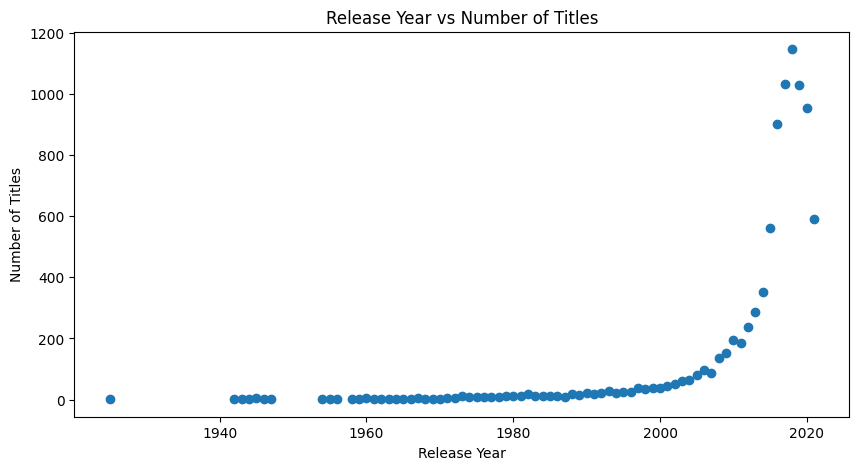

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    year_counts.index,
    year_counts.values
)

plt.title('Release Year vs Number of Titles')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

### Insight from this analysis :

Most Netflix content originates from recent years, indicating a strong focus on contemporary entertainment while maintaining a smaller collection of older titles.

## Analysis 7: Movie Duration Analysis
What is the typical duration of movies available on Netflix?

In [ ]:
movie_df = df[df['type'] == 'Movie'].copy()

# Extract only the numeric part
movie_df['duration_minutes'] = (
    movie_df['duration']
    .str.extract(r'(\d+)')[0]
)

# Convert to numeric safely
movie_df['duration_minutes'] = pd.to_numeric(
    movie_df['duration_minutes'],
    errors='coerce'
)

# Remove rows where duration could not be converted
movie_df = movie_df.dropna(subset=['duration_minutes'])

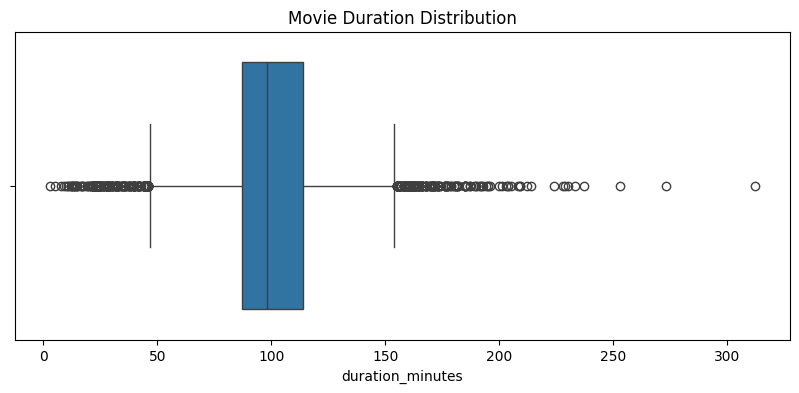

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=movie_df['duration_minutes']
)

plt.title('Movie Duration Distribution')

plt.show()

### Insight from this analysis :

Most movies fall within a moderate duration range, suggesting that Netflix primarily hosts standard feature-length films rather than extremely short or unusually long productions.

## Analysis 8: Most Featured Directors
Which directors have the highest number of titles on Netflix?

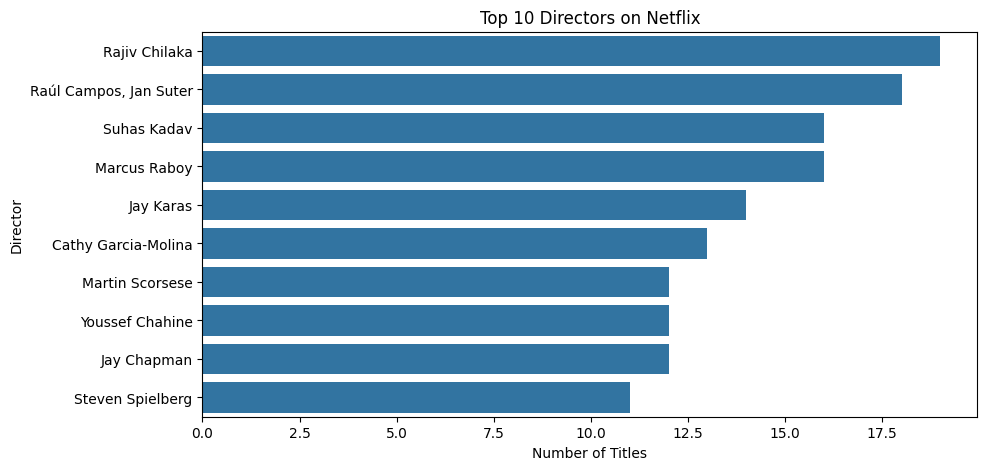

In [ ]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.show()

## Analysis 9: Most Featured Actors
Which actors appear most frequently in Netflix content?

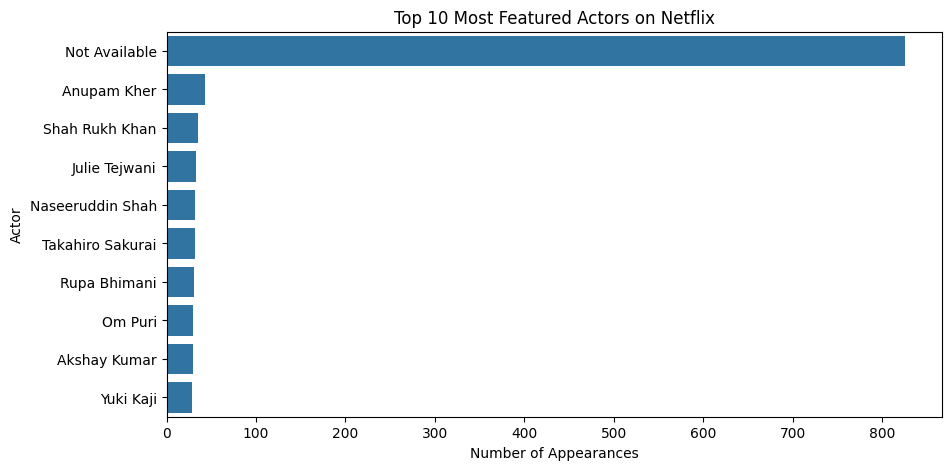

In [ ]:
actors = df['cast'].dropna().str.split(', ').explode()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)

plt.title('Top 10 Most Featured Actors on Netflix')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')

plt.show()

### Insight from this analysis :

Certain actors appear repeatedly across Netflix titles, indicating their popularity and strong presence within the platform's content library.

## Analysis 10: Movies and TV Shows Added Over Time
How has the addition of Movies and TV Shows changed over the years?

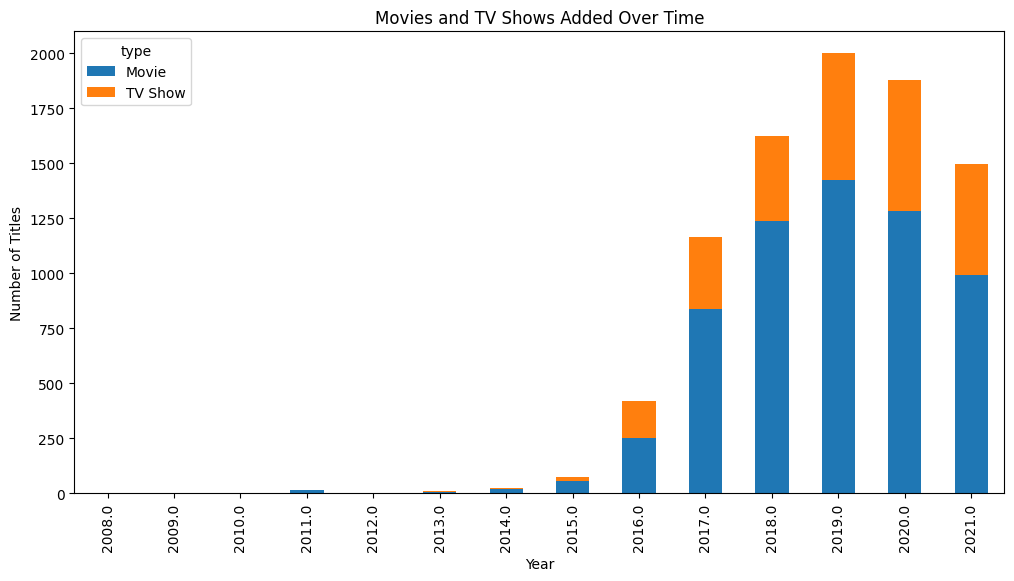

In [ ]:
content_by_year = pd.crosstab(
    df['year_added'],
    df['type']
)

content_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Movies and TV Shows Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

### Insight from this analysis :

Both Movies and TV Shows increased significantly over time, although Movies consistently represented the larger share of Netflix's content additions.

## Correlation Analysis


Are there any relationships between the numerical variables in the dataset?

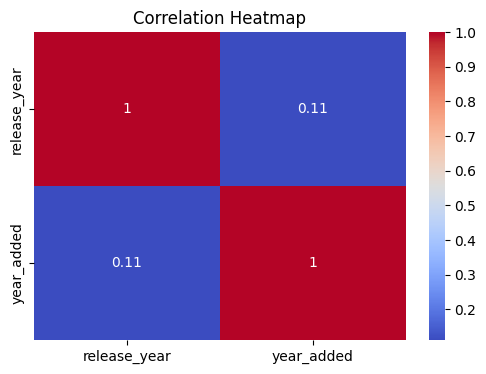

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight from this analysis :

The numerical variables show limited correlation, indicating that each feature captures distinct aspects of Netflix content.

# Key Findings from this project :

Based on the exploratory data analysis performed on the Netflix dataset, the following key findings were observed:

1. Movies constitute a significantly larger portion of Netflix's catalog compared to TV Shows.

2. Netflix experienced substantial growth in content additions, especially during recent years.

3. The United States contributes the highest number of titles, followed by several other major content-producing countries.

4. TV-MA and TV-14 are among the most common content ratings, indicating a strong focus on mature and teenage audiences.

5. Drama, International Movies, and Comedy are among the most frequently occurring genres.

6. Most Netflix content originates from recent release years, reflecting a focus on contemporary entertainment.

7. The majority of movies have a standard feature-film duration, with a few notable outliers.

8. Certain directors and actors appear repeatedly across Netflix titles, demonstrating strong representation on the platform.

9. Movies have consistently outnumbered TV Shows in content additions over time.

10. Correlation analysis revealed limited relationships among the numerical variables available in the dataset.

# Conclusion

This project conducted an Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis involved data cleaning, visualization, trend identification, and correlation analysis to better understand Netflix's content library.

The findings indicate that Netflix primarily focuses on movie content, has expanded its catalog significantly over the years, and serves a diverse global audience through a wide range of genres, ratings, and international content.

Overall, the project demonstrates how data analysis and visualization techniques can be used to extract meaningful insights from large real-world datasets and support data-driven decision making.